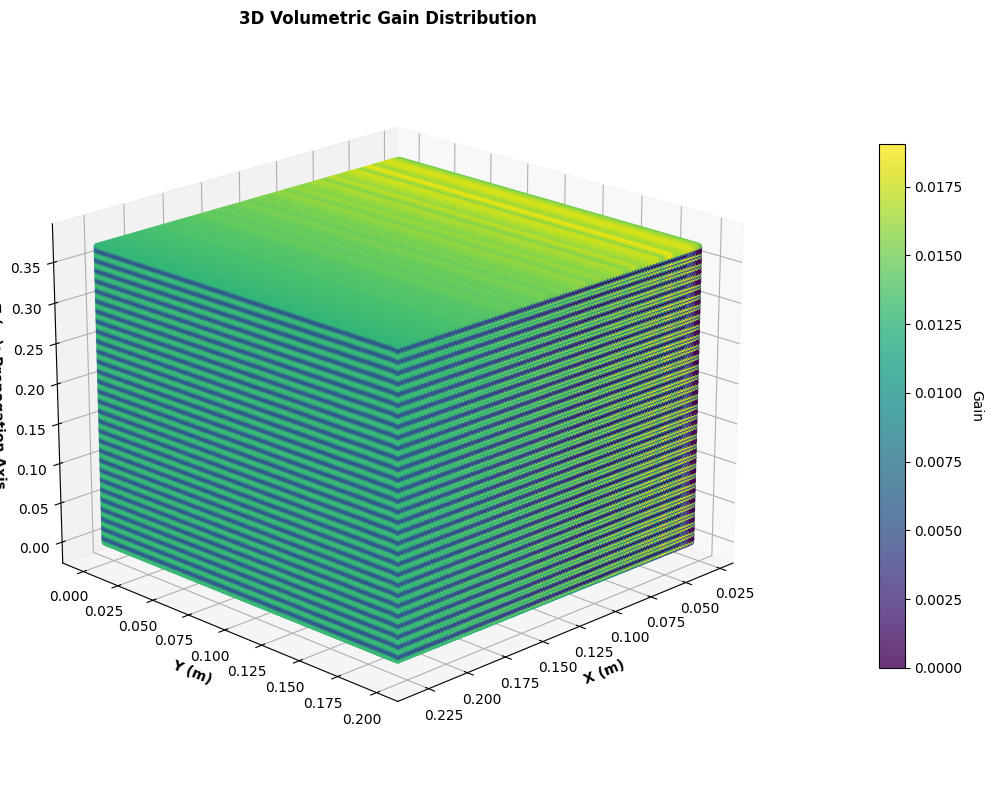

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'gain_data_50KW.txt'
df = pd.read_csv(file_path, sep='\t', header=0)
df.columns = ["x", 'z', 'y', 'gain']

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['x'], df['y'], df['z'], c=df['gain'], cmap='viridis', marker='o', s=15, alpha=0.8)
cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Gain', rotation=270, labelpad=15)
ax.set_xlabel('X (m)', fontweight='bold')
ax.set_ylabel('Y (m)', fontweight='bold')
ax.set_zlabel('Z (m): Propagation Axis', fontweight='bold')
ax.set_title('3D Volumetric Gain Distribution', fontweight='bold')
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

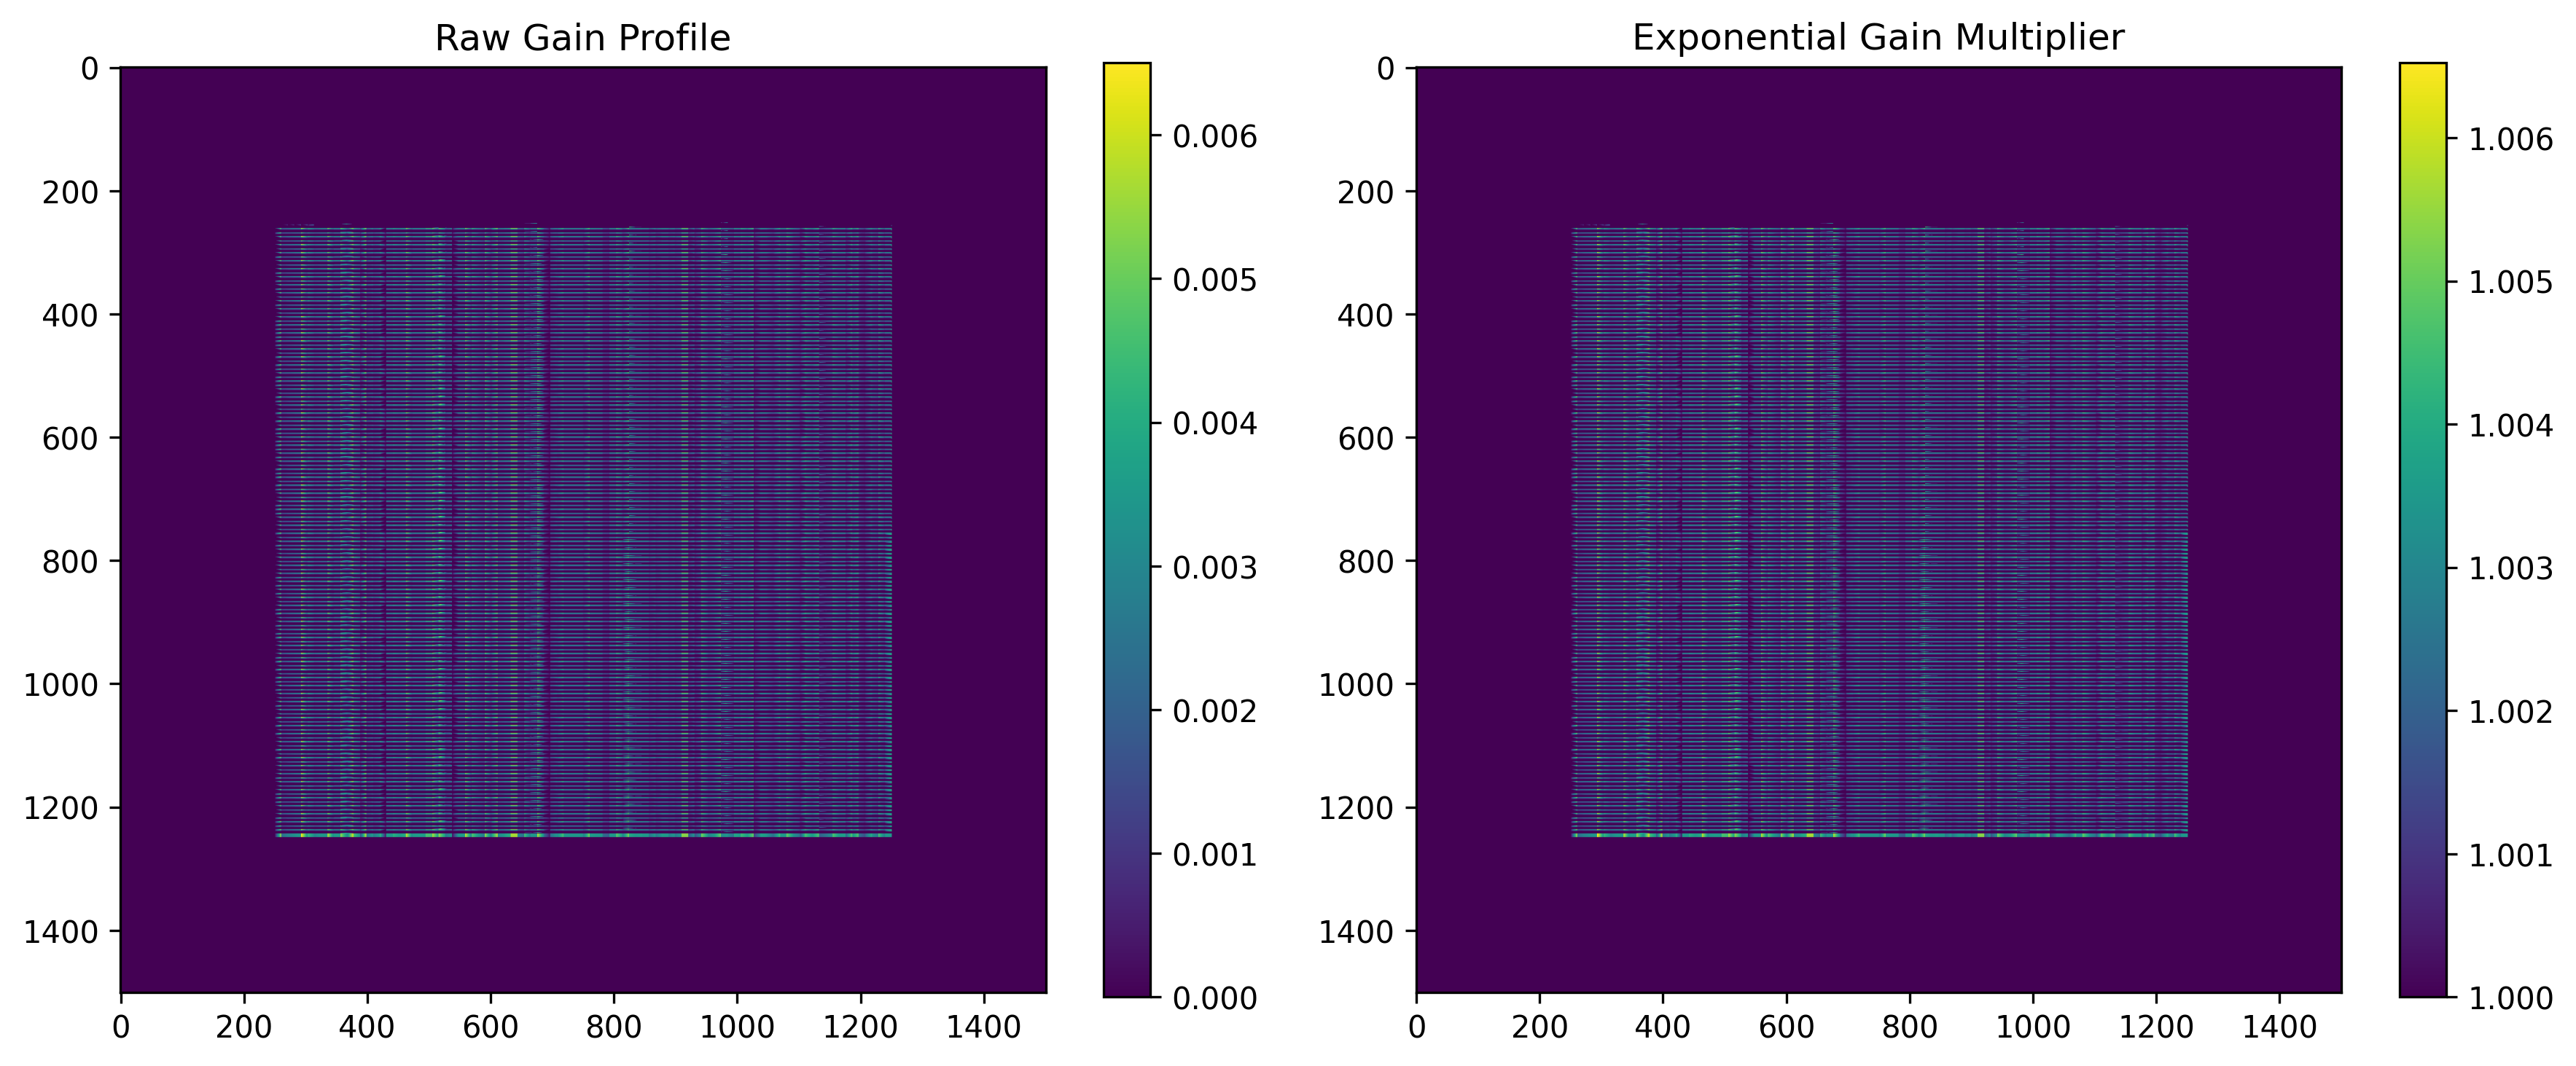

In [2]:
from gain_processor import load_and_process_gain
import numpy as np
import matplotlib.pyplot as plt

grid = np.linspace(-0.015, 0.015, 1501)
X, Y = np.meshgrid(grid, grid) 

exp_multiplier, gain_profile = load_and_process_gain(filepath="gain_data_50KW.txt", X_cavity=X, Y_cavity=Y)

plt.figure(figsize=(12, 6), dpi=300)
plt.subplot(121)
plt.imshow(gain_profile)
plt.title("Raw Gain Profile")
plt.colorbar(shrink=0.75)


plt.subplot(122)
plt.imshow(exp_multiplier)
plt.colorbar(shrink=0.75)
plt.title("Exponential Gain Multiplier")

plt.tight_layout()
plt.show()
